# Fase 2

# Subible 1

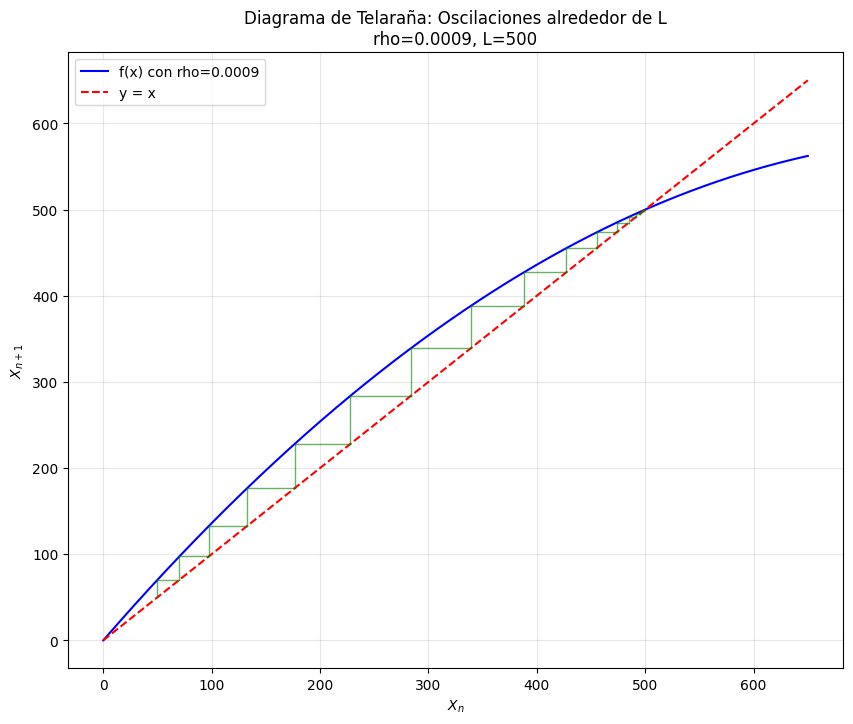

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def modelo_logistico(x, rho, L):
    return x + rho * x * (L - x)

# Parámetros solicitados
rho_grande = 0.0009
L_fijo = 500
x0_inicial = 50
pasos = 30

# Visualización
x_range = np.linspace(0, L_fijo * 1.3, 500)
plt.figure(figsize=(10, 8))
plt.plot(x_range, modelo_logistico(x_range, rho_grande, L_fijo), 'b', label=f'f(x) con rho={rho_grande}')
plt.plot(x_range, x_range, 'r--', label='y = x')

x = x0_inicial
for i in range(pasos):
    y = modelo_logistico(x, rho_grande, L_fijo)
    plt.plot([x, x], [x, y], 'g', lw=1, alpha=0.6)
    plt.plot([x, y], [y, y], 'g', lw=1, alpha=0.6)
    x = y

plt.title(f'Diagrama de Telaraña: Oscilaciones alrededor de L\nrho={rho_grande}, L={L_fijo}')
plt.xlabel('$X_n$')
plt.ylabel('$X_{n+1}$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

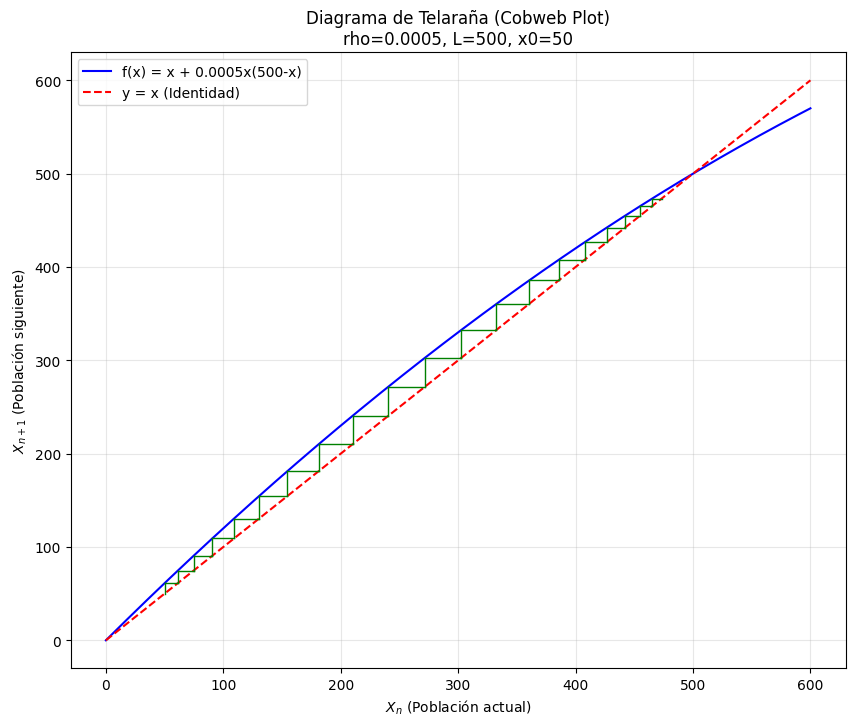

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def modelo_logistico(x, rho, L):
    """Función de iteración del modelo logístico discreto."""
    return x + rho * x * (L - x)

def plot_cobweb(rho, L, x0, iteraciones):
    # 1. Configuración del dominio para las curvas
    x_range = np.linspace(0, L * 1.2, 500)
    y_logistica = modelo_logistico(x_range, rho, L)

    plt.figure(figsize=(10, 8))

    # 2. Graficar la función de iteración y la recta y=x
    plt.plot(x_range, y_logistica, 'b', label=f'f(x) = x + {rho}x({L}-x)')
    plt.plot(x_range, x_range, 'r--', label='y = x (Identidad)')

    # 3. Lógica de la "Telaraña"
    x = x0
    for i in range(iteraciones):
        y = modelo_logistico(x, rho, L)

        # Trazar línea vertical desde el eje x (o paso anterior) hasta la curva
        plt.plot([x, x], [x, y], 'g', lw=1)
        # Trazar línea horizontal desde la curva hasta la recta identidad
        plt.plot([x, y], [y, y], 'g', lw=1)

        x = y # El nuevo x para la siguiente iteración es el y actual

    # 4. Detalles del gráfico
    plt.title(f'Diagrama de Telaraña (Cobweb Plot)\nrho={rho}, L={L}, x0={x0}')
    plt.xlabel('$X_n$ (Población actual)')
    plt.ylabel('$X_{n+1}$ (Población siguiente)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- PARÁMETROS PARA TU ANÁLISIS ---
# Prueba con rho pequeño (0.001) y luego uno más grande (0.005)
plot_cobweb(rho=0.0005, L=500, x0=50, iteraciones=20)

*texto en cursiva*# Nueva sección

# Subible 2

<>:46: SyntaxWarning: invalid escape sequence '\i'
<>:46: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_8156/2777432087.py:46: SyntaxWarning: invalid escape sequence '\i'
  plt.title('Análisis de Sensibilidad: Tiempo de Convergencia\nModelo Logístico Discreto ($\\rho \in [0.0005, 0.0009]$)', fontsize=14)


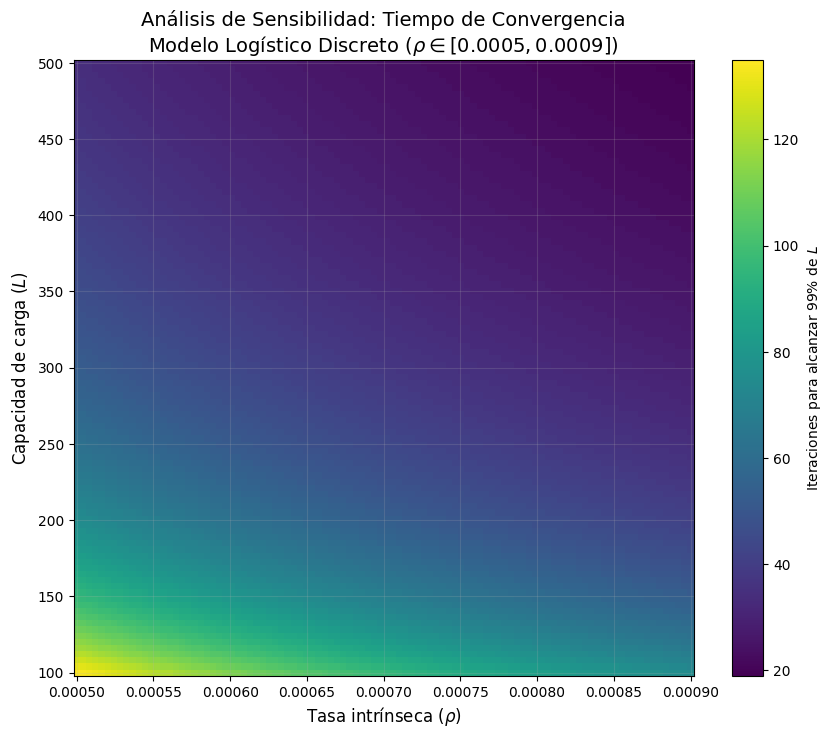

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def tiempo_convergencia(rho, L, x0, tol=0.99, max_iter=150):
    """
    Calcula iteraciones necesarias para que la población alcance el 99% de L.
    """
    x = x0
    for i in range(max_iter):
        # Frenos de emergencia (aunque en este rango estable no deberían activarse)
        if x < 0 or x > L * 3:
            return max_iter

        # Condición de éxito: alcanzar la tolerancia respecto a L
        if x >= L * tol:
            return i

        # Ecuación en diferencias iterativa
        x = x + rho * x * (L - x)

    return max_iter

# 1. Definir los rangos de prueba con tus nuevos valores
L_vals = np.linspace(100, 500, 100)
# Ajuste del rango de rho: desde el "pequeño" (0.0005) hasta el "alto" (0.0009)
rho_vals = np.linspace(0.0005, 0.0009, 100)

# Crear grillas 2D para evaluar cada combinación
Rho_grid, L_grid = np.meshgrid(rho_vals, L_vals)
Z = np.zeros_like(Rho_grid)

# 2. Calcular el tiempo de convergencia para cada par (rho, L)
x0_fijo = 10
for i in range(len(L_vals)):
    for j in range(len(rho_vals)):
        Z[i, j] = tiempo_convergencia(Rho_grid[i, j], L_grid[i, j], x0=x0_fijo)

# 3. Visualización con Matplotlib
plt.figure(figsize=(10, 8))

# Generar el mapa de calor
mapa = plt.pcolormesh(Rho_grid, L_grid, Z, cmap='viridis', shading='auto')

# Detalles del gráfico requeridos para tu informe
plt.colorbar(mapa, label='Iteraciones para alcanzar 99% de $L$')
plt.title('Análisis de Sensibilidad: Tiempo de Convergencia\nModelo Logístico Discreto ($\\rho \in [0.0005, 0.0009]$)', fontsize=14)
plt.xlabel(r'Tasa intrínseca ($\rho$)', fontsize=12)
plt.ylabel(r'Capacidad de carga ($L$)', fontsize=12)
plt.grid(True, alpha=0.2)

plt.show()

# Subible 3

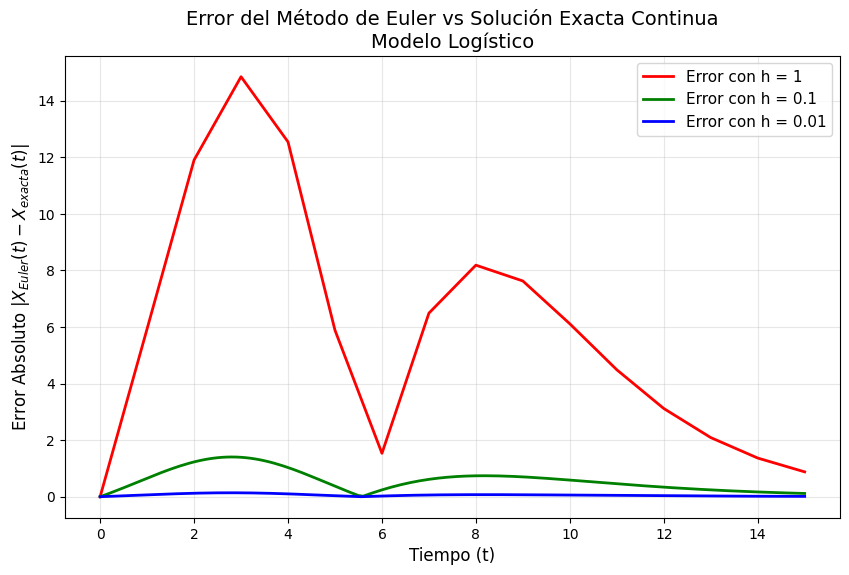

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def solucion_exacta(t, alpha, L, x0):
    """Solución analítica exacta de la EDO logística continua."""
    C = (L - x0) / x0
    return L / (1 + C * np.exp(-alpha * t))

def euler_logistico(alpha, L, x0, t_end, h):
    """Aproximación numérica usando el Método de Euler."""
    # Crear un arreglo de tiempos espaciados por h
    t = np.arange(0, t_end + h, h)
    X = np.zeros(len(t))
    X[0] = x0

    for n in range(0, len(t) - 1):
        # Derivada en el instante actual: g(X)
        dX_dt = alpha * X[n] * (1 - X[n] / L)
        # Siguiente paso de Euler
        X[n+1] = X[n] + h * dX_dt

    return t, X

# 1. Parámetros de la simulación
alpha = 0.5  # Tasa de crecimiento
L = 500      # Capacidad de carga
x0 = 100     # Población inicial
t_end = 15   # Tiempo total a simular

# 2. Tamaños de paso h requeridos en la Fase 2
pasos_h = [1, 0.1, 0.01]
colores = ['red', 'green', 'blue']

plt.figure(figsize=(10, 6))

# 3. Calcular y graficar el error para cada tamaño de paso
for h, color in zip(pasos_h, colores):
    # Obtener tiempos y población estimada por Euler
    t_euler, X_euler = euler_logistico(alpha, L, x0, t_end, h)

    # Evaluar la solución matemática exacta en esos mismos instantes de tiempo
    X_exacta = solucion_exacta(t_euler, alpha, L, x0)

    # Calcular el error absoluto
    error_absoluto = np.abs(X_euler - X_exacta)

    # Graficar la curva de error
    plt.plot(t_euler, error_absoluto, color=color, linewidth=2, label=f'Error con h = {h}')

# 4. Detalles del gráfico para el informe
plt.title('Error del Método de Euler vs Solución Exacta Continua\nModelo Logístico', fontsize=14)
plt.xlabel('Tiempo (t)', fontsize=12)
plt.ylabel('Error Absoluto $|X_{Euler}(t) - X_{exacta}(t)|$', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.show()